In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage


In [ ]:
# Binary image (1 = object, 0 = background)
binary_image = np.array([
    [0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 0],
    [0, 1, 1, 1, 1, 0],
    [0, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0]
])


In [ ]:
# Compute Euclidean Distance Transform
distance_map = ndimage.distance_transform_edt(binary_image)


In [ ]:
def medial_axis(distance_map):
    medial = np.zeros_like(distance_map)

    for i in range(1, distance_map.shape[0] - 1):
        for j in range(1, distance_map.shape[1] - 1):
            local = distance_map[i-1:i+2, j-1:j+2]
            if distance_map[i, j] == np.max(local) and distance_map[i, j] > 0:
                medial[i, j] = 1

    return medial


In [ ]:
medial_axis_image = medial_axis(distance_map)


In [ ]:
radius_function = distance_map * medial_axis_image


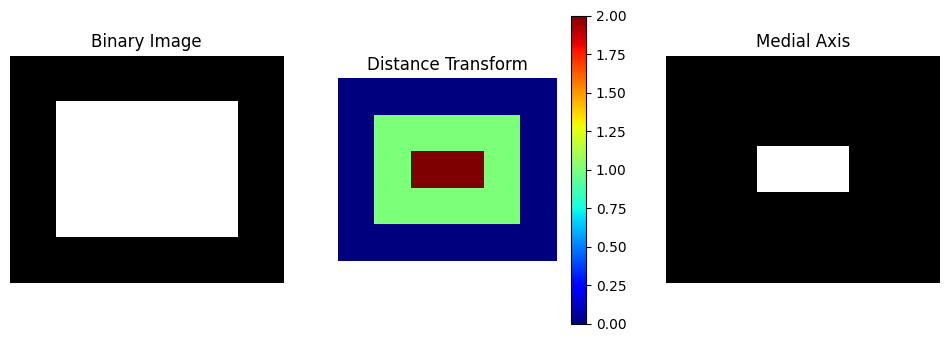

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Binary Image")
plt.imshow(binary_image, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Distance Transform")
plt.imshow(distance_map, cmap="jet")
plt.colorbar()
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Medial Axis")
plt.imshow(medial_axis_image, cmap="gray")
plt.axis("off")

plt.show()
